In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt
from pybaseball import batting_stats
import logging
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from arviz import hdi
from sklearn.metrics import root_mean_squared_error
import scipy.stats as stats

tf.get_logger().setLevel(logging.FATAL)  # suppress TF warnings

In [15]:
# --- Load data ---
raw_2018 = batting_stats(2018)
raw_2019 = batting_stats(2019)
raw_2021 = batting_stats(2021)
raw_2022 = batting_stats(2022)
raw_2023 = batting_stats(2023)
raw_2024 = batting_stats(2024)
raw_2025 = batting_stats(2025)

# --- Combine ---
raw_data = pd.concat([raw_2018, raw_2019, raw_2021, raw_2022, raw_2023, raw_2024, raw_2025])

# --- Select columns ---
df = raw_data[["Season", "Name", "Team", "Pos", "Age", "PA", 
               "AVG", "OBP", "SLG", "OPS", "xBA", "xwOBA", "K%", "Contact%", 
               "EV", "Barrel%", "HardHit%"]]

# --- Filter for players with 500+ PA ---
df = df[df['PA'] >= 500].copy()

#save data
#raw_data.to_csv("C:/Users/Andrew/baseball/data/batting_stats_raw_2021_2025.csv", index=False)
#df.to_csv("C:/Users/Andrew/baseball/data/batting_stats_filtered_2021_2025.csv", index=False)

In [16]:
print(f"Total rows: {len(df)}")
print(f"Total players: {df['Name'].nunique()}")
print(f"Seasons: {sorted(df['Season'].unique().tolist())}")

Total rows: 946
Total players: 377
Seasons: [2018, 2019, 2021, 2022, 2023, 2024, 2025]


In [39]:
# --- Sort by player and season ---
df = df.sort_values(['Name', 'Season']).reset_index(drop=True)

# --- Create next year AVG target ---
df['AVG_next'] = df.groupby('Name')['AVG'].shift(-1)

# --- Split into training and prediction sets ---
model_df = df[df['AVG_next'].notna()].copy()  # has a next year AVG
model_df = model_df[model_df['Season'] != 2024].copy()  # remove 2024 from model
df_2024 = df[df['Season'] == 2024].copy()     # we are predicting 2025 with 2024 data

# --- Define features and target ---
model_df['Age2'] = model_df['Age'] ** 2 # age is non-linear
df_2024['Age2'] = df_2024['Age'] ** 2 # age is non-linear
features = ['Age', 'Age2', "AVG", "xBA"] 
target = 'AVG_next'

#print(model_df[['xBA', 'xwOBA']].corr())

# --- Standardize Features ---
scaler_X = StandardScaler()
X = scaler_X.fit_transform(model_df[features]) #standardize all features
X_2024 = scaler_X.transform(df_2024[features])  # use same scaler, don't refit
y = model_df[target].values # not standardized but bounded inside [0,1]


print(f"Seasons in model_df: {sorted(model_df['Season'].unique().tolist())}")
print(f"Any nulls in X: {np.isnan(X).any()}")
print(f"Any nulls in X: {np.isnan(X).any()}")
print(f"Any nulls in X_2024: {np.isnan(X_2024).any()}")
print(f"Training rows: {len(model_df)}")
print(f"Players to predict: {len(df_2024)}")
print(f"y mean: {y.mean():.3f}, y std: {y.std():.3f}")
print(model_df[["Season", "Name",'Age', "AVG", "xBA"]].head(10))

Seasons in model_df: [2018, 2019, 2021, 2022, 2023]
Any nulls in X: False
Any nulls in X: False
Any nulls in X_2024: False
Training rows: 481
Players to predict: 129
y mean: 0.263, y std: 0.028
    Season             Name  Age    AVG    xBA
2     2021      Aaron Judge   29  0.287  0.302
3     2022      Aaron Judge   30  0.311  0.304
8     2019     Adam Frazier   27  0.278  0.275
9     2021     Adam Frazier   29  0.305  0.286
11    2018       Adam Jones   32  0.281  0.268
14    2023  Adley Rutschman   25  0.277  0.289
16    2021    Adolis Garcia   28  0.243  0.216
17    2022    Adolis Garcia   29  0.250  0.242
18    2023    Adolis Garcia   30  0.245  0.245
24    2022        Alec Bohm   25  0.280  0.287


In [29]:
# checking boundaries for beta distribution 
# (it will break at the edges)
print(f"y == 0: {(y == 0).sum()}")
print(f"y == 1: {(y == 1).sum()}")

y == 0: 0
y == 1: 0


In [30]:
with pm.Model(coords={"features": features}) as model:
    
    # --- Create Data containers ---
    X_data = pm.Data('X_data', X)
    y_data = pm.Data('y_data', y)
    
    # --- Create Model ---
    alpha = pm.Normal('alpha', mu=0, sigma=1.0)
    betas = pm.Normal('betas', mu=0, sigma=1.0, dims="features")  

    mu = pm.Deterministic('mu', pm.math.sigmoid(alpha + (X_data * betas).sum(axis=1)))
    kappa = pm.HalfNormal('kappa', sigma=50)
    
    # --- Likelihood ---
    y_obs = pm.Beta('y_obs', mu=mu, nu=kappa, observed=y_data)

    # --- Sample ---
    trace = pm.sample(2000, tune=2000, chains=4, target_accept=0.9, cores=4)

c:\Users\Andrew\anaconda3\envs\python_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, betas, kappa]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 150 seconds.


In [31]:
az.summary(trace, var_names=['alpha', 'betas', 'kappa'])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,-1.029,0.006,-1.041,-1.017,0.000,0.000,6205.0,5017.0,1.0
betas[Age],-0.026,0.076,-0.170,0.118,0.001,0.001,4126.0,3567.0,1.0
betas[Age2],0.018,0.077,-0.116,0.173,0.001,0.001,4124.0,3734.0,1.0
betas[AVG],0.035,0.011,0.015,0.055,0.000,0.000,5342.0,4839.0,1.0
betas[xBA],0.030,0.011,0.010,0.049,0.000,0.000,5282.0,4857.0,1.0
kappa,272.234,16.396,241.036,302.430,0.211,0.222,6199.0,4982.0,1.0


In [32]:
for i, feature in enumerate(features):
    row = az.summary(trace, var_names=['betas']).iloc[i]
    contains_zero = row['hdi_3%'] < 0 < row['hdi_97%']
    zero_msg = " ⚠️ HDI contains zero" if contains_zero else ""
    print(f"{feature:12s}  mean={row['mean']:+.4f}  hdi=[{row['hdi_3%']:+.4f}, {row['hdi_97%']:+.4f}]{zero_msg}")

Age           mean=-0.0260  hdi=[-0.1700, +0.1180] ⚠️ HDI contains zero
Age2          mean=+0.0180  hdi=[-0.1160, +0.1730] ⚠️ HDI contains zero
AVG           mean=+0.0350  hdi=[+0.0150, +0.0550]
xBA           mean=+0.0300  hdi=[+0.0100, +0.0490]


In [40]:
with model:
    pm.set_data({
        'X_data': X_2024,
        'y_data': np.full(len(df_2024), 0.111)
    })
    ppc_2024 = pm.sample_posterior_predictive(trace)

# extract predictions
pred_samples = ppc_2024.posterior_predictive['y_obs'].values.reshape(-1, len(df_2024))
print(f"pred_samples shape: {pred_samples.shape}")

hdi_vals = hdi(pred_samples, hdi_prob=0.94)
df_2024['predicted_AVG'] = pred_samples.mean(axis=0)
df_2024['pred_hdi_low'] = hdi_vals[:, 0]
df_2024['pred_hdi_high'] = hdi_vals[:, 1]

df_2024[['Name', 'AVG', 'xBA', 'predicted_AVG', 'pred_hdi_low', 'pred_hdi_high']]\
      .sort_values('predicted_AVG', ascending=False)\
      .head(20)

Sampling: [y_obs]


Output()

pred_samples shape: (8000, 129)


C:\Users\Andrew\AppData\Local\Temp\ipykernel_13732\404291152.py:12: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi_vals = hdi(pred_samples, hdi_prob=0.94)


,Name,AVG,xBA,predicted_AVG,pred_hdi_low,pred_hdi_high
100,Bobby Witt Jr.,0.332,0.309,0.295129,0.241361,0.345007
883,Vladimir Guerrero Jr.,0.323,0.317,0.294893,0.242586,0.346179
567,Luis Arraez,0.314,0.310,0.288955,0.240233,0.343064
4,Aaron Judge,0.322,0.305,0.286985,0.235150,0.337621
801,Shohei Ohtani,0.310,0.310,0.286749,0.237076,0.338751
364,Jackson Merrill,0.292,0.300,0.284286,0.231798,0.334918
936,Yordan Alvarez,0.308,0.300,0.284120,0.230919,0.333819
490,Juan Soto,0.288,0.311,0.282650,0.234013,0.335479
917,Yainer Diaz,0.299,0.297,0.282248,0.231876,0.335065
817,Steven Kwan,0.292,0.283,0.276695,0.226524,0.327891


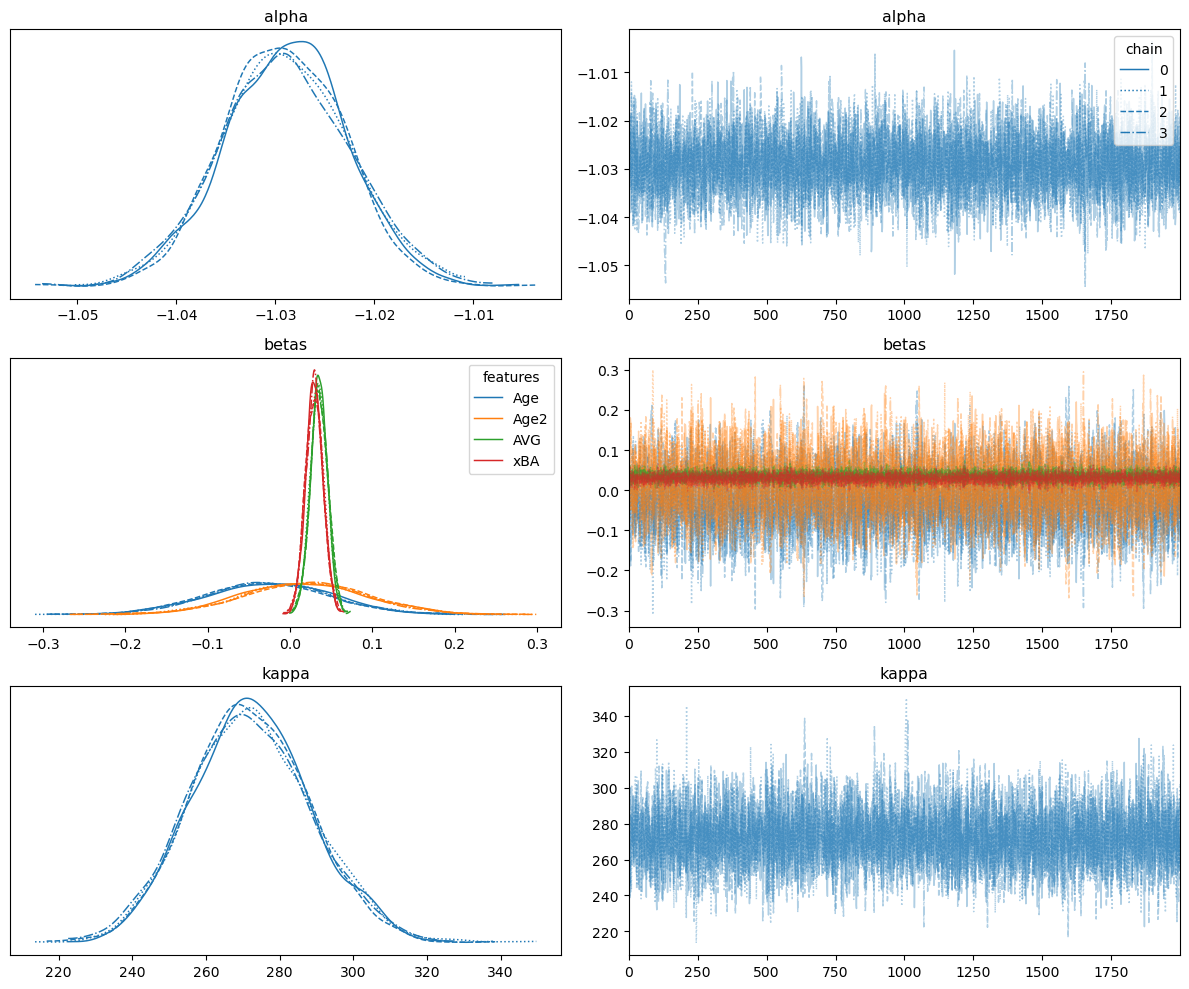

In [34]:
az.plot_trace(trace, var_names=['alpha', 'betas', 'kappa'], 
              figsize=(12, 10), legend=True)
plt.tight_layout()
plt.show()

In [35]:
# --- Drop players without a known 2025 AVG ---
eval_df = df_2024.dropna(subset=['AVG_next']).copy()
print(f"Players with known 2025 AVG: {len(eval_df)} / {len(df_2024)}")

# --- RMSE ---
rmse = root_mean_squared_error(eval_df['AVG_next'], eval_df['predicted_AVG'])
print(f"RMSE: {rmse:.4f}")

# --- Correlation ---
corr, pval = stats.pearsonr(eval_df['AVG_next'], eval_df['predicted_AVG'])
print(f"Pearson correlation: {corr:.4f}")
print(f"P-value: {pval:.4f}")

# --- Mean bias ---
bias = (eval_df['predicted_AVG'] - eval_df['AVG_next']).mean()
print(f"Mean bias: {bias:+.4f}")

# --- Coverage ---
coverage = ((eval_df['AVG_next'] >= eval_df['pred_hdi_low']) & 
            (eval_df['AVG_next'] <= eval_df['pred_hdi_high'])).mean()
print(f"HDI coverage: {coverage:.1%}")

Players with known 2025 AVG: 88 / 129
RMSE: 0.0216
Pearson correlation: 0.4766
P-value: 0.0000
Mean bias: +0.0017
HDI coverage: 97.7%


Sampling: [y_obs]


Output()

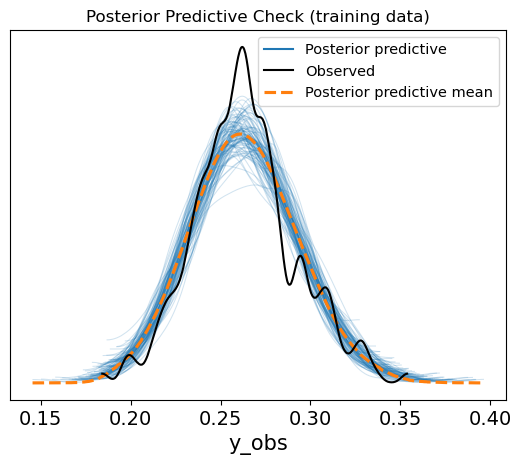

In [36]:
# regenerate ppc on training data
with model:
    pm.set_data({'X_data': X, 'y_data': y})
    ppc_train = pm.sample_posterior_predictive(trace)

# now plot against real observed values
az.plot_ppc(ppc_train, num_pp_samples=100)
plt.title('Posterior Predictive Check (training data)')
plt.show()

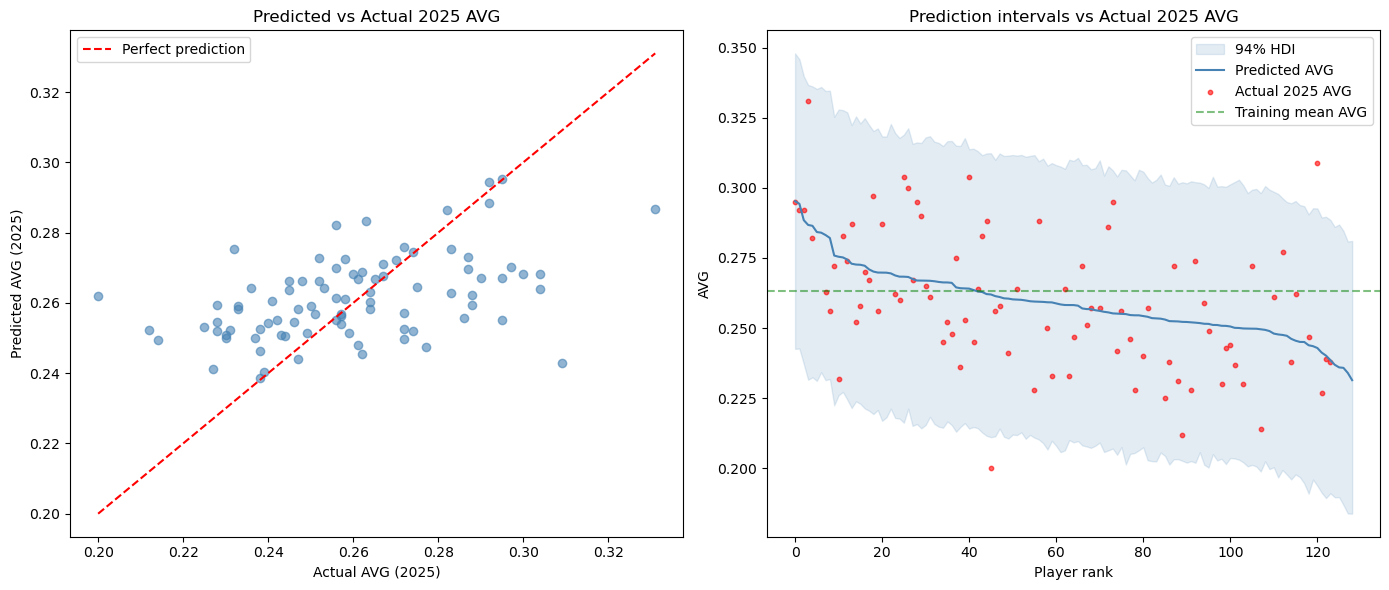

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# --- Plot 1: Predicted vs Actual 2025 AVG ---
ax = axes[0]
ax.scatter(df_2024['AVG_next'], df_2024['predicted_AVG'], alpha=0.6, color='steelblue')

min_val = min(df_2024['AVG_next'].min(), df_2024['predicted_AVG'].min())
max_val = max(df_2024['AVG_next'].max(), df_2024['predicted_AVG'].max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect prediction')

ax.set_xlabel('Actual AVG (2025)')
ax.set_ylabel('Predicted AVG (2025)')
ax.set_title('Predicted vs Actual 2025 AVG')
ax.legend()

# --- Plot 2: Prediction intervals vs Actual 2025 AVG ---
ax = axes[1]
df_sorted = df_2024.sort_values('predicted_AVG', ascending=False).reset_index(drop=True)

ax.fill_between(
    range(len(df_sorted)),
    df_sorted['pred_hdi_low'],
    df_sorted['pred_hdi_high'],
    alpha=0.15, color='steelblue', label='94% HDI'
)
ax.plot(range(len(df_sorted)), df_sorted['predicted_AVG'],
        color='steelblue', linewidth=1.5, label='Predicted AVG')
ax.scatter(range(len(df_sorted)), df_sorted['AVG_next'],
           color='red', s=10, alpha=0.6, label='Actual 2025 AVG')

ax.axhline(y.mean(), color='green', linestyle='--', alpha=0.5, label='Training mean AVG')

ax.set_xlabel('Player rank')
ax.set_ylabel('AVG')
ax.set_title('Prediction intervals vs Actual 2025 AVG')
ax.legend()

plt.tight_layout()
plt.show()

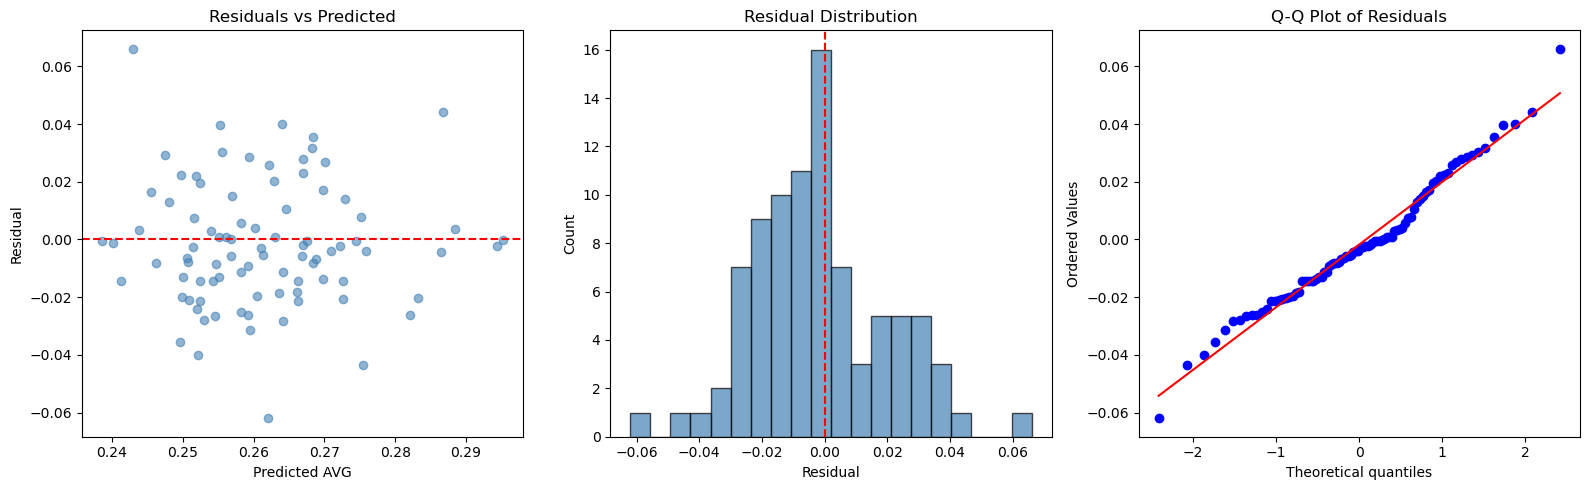

In [38]:
residuals = eval_df['AVG_next'].values - eval_df['predicted_AVG'].values

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Residuals vs Predicted ---
ax = axes[0]
ax.scatter(eval_df['predicted_AVG'], residuals, alpha=0.6, color='steelblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Predicted AVG')
ax.set_ylabel('Residual')
ax.set_title('Residuals vs Predicted')

# --- Residuals Histogram ---
ax = axes[1]
ax.hist(residuals, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_xlabel('Residual')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution')

# --- Q-Q Plot ---
ax = axes[2]
stats.probplot(residuals, plot=ax)
ax.set_title('Q-Q Plot of Residuals')

plt.tight_layout()
plt.show()